***LAB 3
Data Preprocessing & Feature Engineering***

This lab focuses on data preprocessing and feature engineering for machine learning.
We will clean messy data, handle missing values, encode categorical features, scale numerical features, and build a complete preprocessing workflow before training models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

***Part 1***

In [87]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df = pd.DataFrame(data)

# Inject missing values (realistic!)
missing_idx = np.random.choice(n, 20, replace=False)
df.loc[missing_idx[:10], 'age'] = np.nan
df.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df.loc[missing_idx[15:], 'cholesterol'] = np.nan

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values per column:")
print(df.isnull().sum())

Dataset shape: (200, 8)

First 5 rows:
    age  blood_pressure  cholesterol   bmi  gender    city smoker  \
0  56.0           171.7        295.2  34.4    Male  Riyadh     No   
1  69.0           112.4        345.2  21.9  Female  Dammam     No   
2  46.0           126.9        253.3  39.9  Female  Jeddah     No   
3  32.0           158.0        214.6  37.7  Female  Riyadh     No   
4  60.0           110.6        309.0  40.8    Male  Makkah    Yes   

   heart_disease  
0              1  
1              0  
2              0  
3              1  
4              1  

Missing values per column:
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64


In [3]:
print('=== Data Types ===')
print(df.dtypes)

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Numeric Ranges (notice the scale differences!) ===')
print(df.describe().round(2))

print('\n=== Categorical Columns ===')
for col in ['gender', 'city', 'smoker']:
    print(f"{col}: {df[col].unique()}")

=== Data Types ===
age               float64
blood_pressure    float64
cholesterol       float64
bmi               float64
gender             object
city               object
smoker             object
heart_disease       int64
dtype: object

=== Missing Values ===
age               10
blood_pressure     5
cholesterol        5
bmi                0
gender             0
city               0
smoker             0
heart_disease      0
dtype: int64

=== Numeric Ranges (notice the scale differences!) ===
          age  blood_pressure  cholesterol     bmi  heart_disease
count  190.00          195.00       195.00  200.00         200.00
mean    49.31          136.03       252.28   29.33           0.44
std     18.71           26.48        60.97    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.00          112.20       205.75   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     65.00          159.75       

In [4]:
df.info()

missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

print(df['city'].value_counts())

print("Column with most missing values:", df.isnull().sum().idxmax())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             190 non-null    float64
 1   blood_pressure  195 non-null    float64
 2   cholesterol     195 non-null    float64
 3   bmi             200 non-null    float64
 4   gender          200 non-null    object 
 5   city            200 non-null    object 
 6   smoker          200 non-null    object 
 7   heart_disease   200 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 12.6+ KB
age               5.0
blood_pressure    2.5
cholesterol       2.5
bmi               0.0
gender            0.0
city              0.0
smoker            0.0
heart_disease     0.0
dtype: float64
city
Dammam    59
Jeddah    52
Riyadh    47
Makkah    42
Name: count, dtype: int64
Column with most missing values: age


***TASK 1: Which column has the most missing values?***

Column with most missing values: age


***Part 2***

In [88]:
from sklearn.impute import SimpleImputer

# Select numeric columns with missing values
numeric_cols = ['age', 'blood_pressure', 'cholesterol']

# Create an imputer that fills NaN with the median
imputer = SimpleImputer(strategy='median')

# Fit on the data and transform
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

# Verify: no more missing values!
print('Missing values after imputation:')
print(df[numeric_cols].isnull().sum())

Missing values after imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64


In [6]:
print(f'Total missing values in entire dataset: {df.isnull().sum().sum()}')
print(f'\nDataset shape (no rows lost!): {df.shape}')
print(df.describe().round(2))

Total missing values in entire dataset: 0

Dataset shape (no rows lost!): (200, 8)
          age  blood_pressure  cholesterol     bmi  heart_disease
count  200.00          200.00       200.00  200.00         200.00
mean    49.34          136.08       252.36   29.33           0.44
std     18.23           26.15        60.20    6.89           0.50
min     18.00           90.50       152.20   18.30           0.00
25%     32.75          112.62       206.15   23.08           0.00
50%     50.00          138.20       255.50   29.05           0.00
75%     64.00          158.70       301.08   34.67           1.00
max     79.00          179.10       348.60   42.00           1.00


***TASK 2 :***

In [66]:
from sklearn.impute import SimpleImputer

numeric_cols = ['age', 'blood_pressure', 'cholesterol']

# Mean imputation
df_mean = df.copy()
mean_imputer = SimpleImputer(strategy='mean')
df_mean[numeric_cols] = mean_imputer.fit_transform(df_mean[numeric_cols])

print("Missing values after mean imputation:")
print(df_mean[numeric_cols].isnull().sum())

# Compare with median imputation
df_median = df.copy()
median_imputer = SimpleImputer(strategy='median')
df_median[numeric_cols] = median_imputer.fit_transform(df_median[numeric_cols])

print("\nMean vs Median filled values:")
for col in numeric_cols:
    mean_val = df_mean.loc[df[col].isnull(), col].iloc[0]
    median_val = df_median.loc[df[col].isnull(), col].iloc[0]
    print(f"{col}: mean={mean_val:.2f}, median={median_val:.2f}, difference={abs(mean_val - median_val):.2f}")

# dropna() experiment
df_dropped = df.dropna()

print("\nUsing df.dropna():")
print("Original shape:", df.shape)
print("After dropna shape:", df_dropped.shape)
print("Rows lost:", len(df) - len(df_dropped))

Missing values after mean imputation:
age               0
blood_pressure    0
cholesterol       0
dtype: int64

Mean vs Median filled values:
age: mean=49.31, median=50.00, difference=0.69
blood_pressure: mean=136.03, median=138.20, difference=2.17
cholesterol: mean=252.28, median=255.50, difference=3.22

Using df.dropna():
Original shape: (200, 8)
After dropna shape: (180, 8)
Rows lost: 20


Using mean imputation fills the missing values successfully, and the filled values are slightly different from median imputation.

Using `df.dropna()` removes rows with missing values, so the dataset becomes smaller.  
For 200 samples, dropping rows is usually not the best choice, so imputation is more suitable.

Dropping rows is better when the number of missing rows is very small, so removing them will not affect the dataset size or quality too much.

***Part 3***

In [89]:
from sklearn.preprocessing import LabelEncoder

# Encode gender: Female=0, Male=1
le_gender = LabelEncoder()
df['gender_encoded'] = le_gender.fit_transform(df['gender'])

# Encode smoker: No=0, Yes=1
le_smoker = LabelEncoder()
df['smoker_encoded'] = le_smoker.fit_transform(df['smoker'])

print('Original vs Encoded:')
print(df[['gender', 'gender_encoded', 'smoker', 'smoker_encoded']].head())

Original vs Encoded:
   gender  gender_encoded smoker  smoker_encoded
0    Male               1     No               0
1  Female               0     No               0
2  Female               0     No               0
3  Female               0     No               0
4    Male               1    Yes               1


In [21]:

#Bouns part

pd.get_dummies(df['city'], prefix='city', drop_first=True)

,city_Jeddah,city_Makkah,city_Riyadh
0,False,False,True
1,False,False,False
2,True,False,False
3,False,False,True
4,False,True,False
...,...,...,...
195,False,True,False
196,True,False,False
197,False,False,False
198,False,True,False


***Bouns Part:***

Using `drop_first=True` removes one dummy column (for one city) to avoid redundancy.
This helps reduce multicollinearity because the dropped city can be inferred from the remaining columns.

In [90]:
# One-Hot Encode the city column
city_dummies = pd.get_dummies(df['city'], prefix='city')

print('One-Hot Encoded cities:')
print(city_dummies.head())

# Add to dataframe and drop original text columns
df = pd.concat([df, city_dummies], axis=1)
df = df.drop(columns=['gender', 'city', 'smoker'])

print(f'\nNew shape: {df.shape}')
print(f'New columns: {list(df.columns)}')

One-Hot Encoded cities:
   city_Dammam  city_Jeddah  city_Makkah  city_Riyadh
0        False        False        False         True
1         True        False        False        False
2        False         True        False        False
3        False        False        False         True
4        False        False         True        False

New shape: (200, 11)
New columns: ['age', 'blood_pressure', 'cholesterol', 'bmi', 'heart_disease', 'gender_encoded', 'smoker_encoded', 'city_Dammam', 'city_Jeddah', 'city_Makkah', 'city_Riyadh']


***TASK 3 :***

In [31]:
print(df.head(10))
print("Number of columns:", df.shape[1])

    age  blood_pressure  cholesterol   bmi  heart_disease  city_Dammam  \
0  56.0           171.7        295.2  34.4              1        False   
1  69.0           112.4        345.2  21.9              0         True   
2  46.0           126.9        253.3  39.9              0        False   
3  32.0           158.0        214.6  37.7              1        False   
4  60.0           110.6        309.0  40.8              1        False   
5  25.0            96.9        204.2  35.4              0        False   
6  78.0           116.1        237.8  32.7              1        False   
7  38.0           104.5        165.7  28.0              0         True   
8  56.0           173.7        155.1  40.4              0         True   
9  75.0           162.7        342.5  38.8              0        False   

   city_Jeddah  city_Makkah  city_Riyadh  
0        False        False         True  
1        False        False        False  
2         True        False        False  
3        Fals

If the city column had 50 unique values, One-Hot encoding would create 50 new columns.
This can be a problem because it increases the number of features and makes the dataset larger and more sparse.

***Part 4***

In [91]:
from sklearn.preprocessing import StandardScaler

feature_cols = ['age', 'blood_pressure', 'cholesterol', 'bmi',
                'gender_encoded', 'smoker_encoded',
                'city_Dammam', 'city_Jeddah',
                'city_Makkah', 'city_Riyadh']
X = df[feature_cols].astype(float).values
y = df['heart_disease'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

import pandas as pd
comparison = pd.DataFrame({
    'Feature': feature_cols,
    'Original Mean': X.mean(axis=0).round(2),
    'Original Std': X.std(axis=0).round(2),
    'Scaled Mean': X_scaled.mean(axis=0).round(2),
    'Scaled Std': X_scaled.std(axis=0).round(2)
})
print(comparison.to_string(index=False))

       Feature  Original Mean  Original Std  Scaled Mean  Scaled Std
           age          49.34         18.19          0.0         1.0
blood_pressure         136.08         26.08         -0.0         1.0
   cholesterol         252.36         60.05          0.0         1.0
           bmi          29.33          6.87         -0.0         1.0
gender_encoded           0.52          0.50         -0.0         1.0
smoker_encoded           0.32          0.47         -0.0         1.0
   city_Dammam           0.30          0.46         -0.0         1.0
   city_Jeddah           0.26          0.44         -0.0         1.0
   city_Makkah           0.21          0.41          0.0         1.0
   city_Riyadh           0.24          0.42          0.0         1.0


/tmp/ipython-input-4217849768.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-4217849768.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],


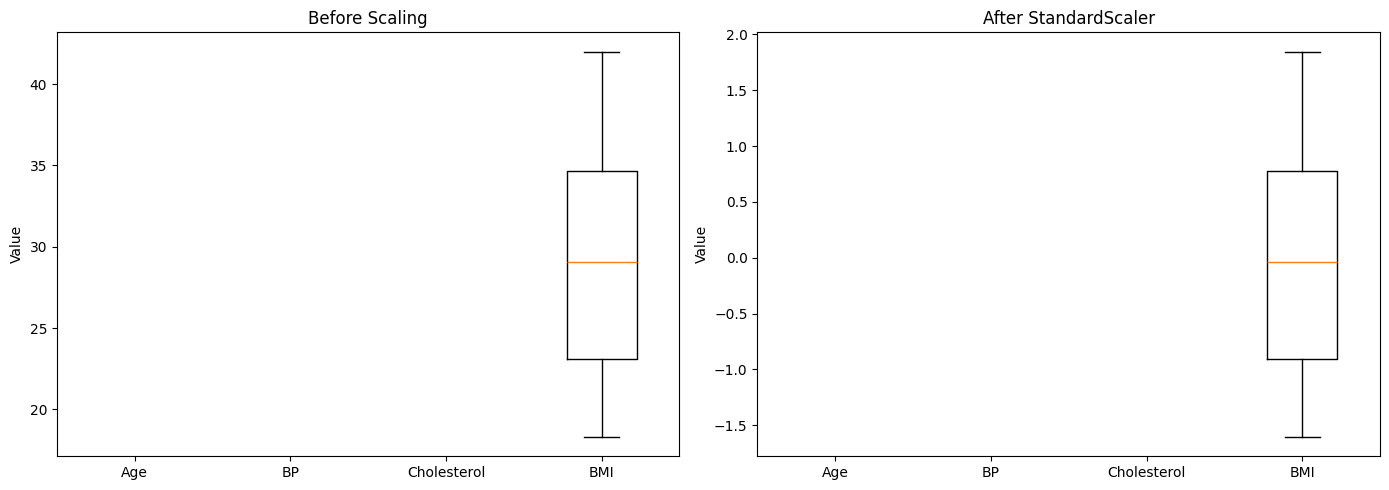

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

axes[1].boxplot([X_scaled[:, 0], X_scaled[:, 1],
                 X_scaled[:, 2], X_scaled[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('After StandardScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

***TASK 4 :***

Min values after MinMaxScaler: [nan nan nan  0.  0.  0.  0.  0.  0.  0.]
Max values after MinMaxScaler: [nan nan nan  1.  1.  1.  1.  1.  1.  1.]


/tmp/ipython-input-2943759060.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
/tmp/ipython-input-2943759060.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([X_minmax[:, 0], X_minmax[:, 1],


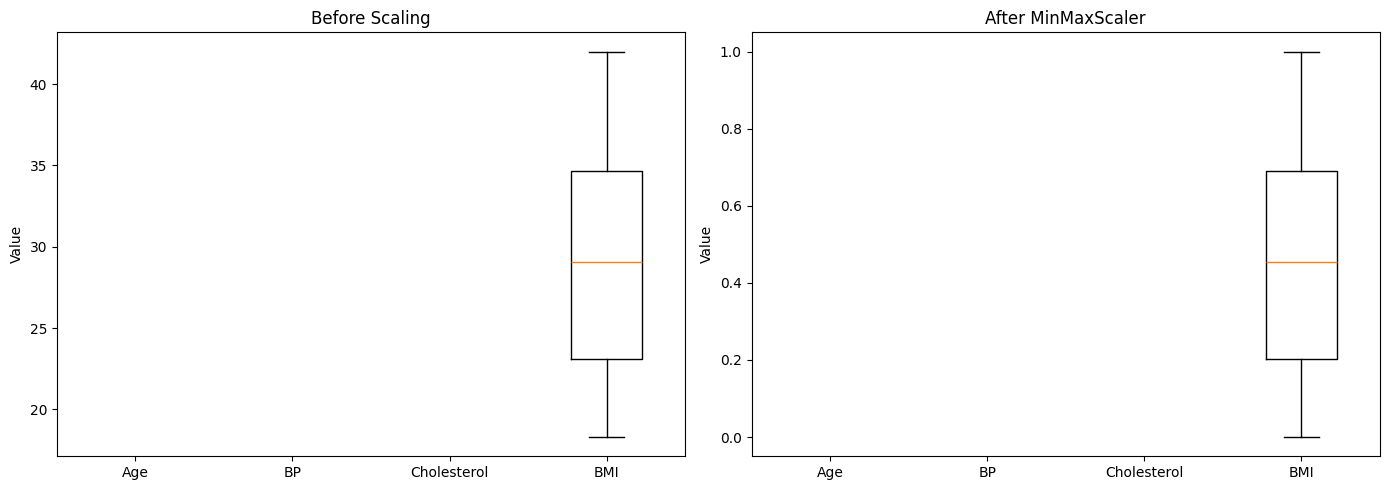

In [72]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

print("Min values after MinMaxScaler:", X_minmax.min(axis=0).round(2))
print("Max values after MinMaxScaler:", X_minmax.max(axis=0).round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot([X[:, 0], X[:, 1], X[:, 2], X[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[0].set_title('Before Scaling')
axes[0].set_ylabel('Value')

axes[1].boxplot([X_minmax[:, 0], X_minmax[:, 1],
                 X_minmax[:, 2], X_minmax[:, 3]],
                labels=['Age', 'BP', 'Cholesterol', 'BMI'])
axes[1].set_title('After MinMaxScaler')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

MinMaxScaler scales feature values to the range [0, 1].

Compared to StandardScaler, MinMaxScaler keeps values within a fixed range, while StandardScaler makes the mean close to 0 and the standard deviation close to 1.

If there are many outliers, StandardScaler is usually a better choice than MinMaxScaler.

***Part 5***

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_s, X_test_s, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# KNN WITHOUT scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
raw_acc = accuracy_score(y_test, knn_raw.predict(X_test))

# KNN WITH scaling
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_s, y_train)
scaled_acc = accuracy_score(y_test, knn_scaled.predict(X_test_s))

print(f'KNN Accuracy WITHOUT scaling: {raw_acc:.2%}')
print(f'KNN Accuracy WITH scaling: {scaled_acc:.2%}')
print(f'Improvement: {(scaled_acc - raw_acc):.2%}')

KNN Accuracy WITHOUT scaling: 67.50%
KNN Accuracy WITH scaling: 50.00%
Improvement: -17.50%


In [93]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree WITHOUT scaling
dt_raw = DecisionTreeClassifier(random_state=42)
dt_raw.fit(X_train, y_train)
dt_raw_acc = accuracy_score(y_test, dt_raw.predict(X_test))

# Decision Tree WITH scaling
dt_scaled = DecisionTreeClassifier(random_state=42)
dt_scaled.fit(X_train_s, y_train)
dt_scaled_acc = accuracy_score(y_test, dt_scaled.predict(X_test_s))

print(f'DT Accuracy WITHOUT scaling: {dt_raw_acc:.2%}')
print(f'DT Accuracy WITH scaling: {dt_scaled_acc:.2%}')

DT Accuracy WITHOUT scaling: 55.00%
DT Accuracy WITH scaling: 52.50%


***TASK 5 :***




In [94]:
for k in [3, 10]:
    knn_raw_k = KNeighborsClassifier(n_neighbors=k)
    knn_raw_k.fit(X_train, y_train)
    raw_k_acc = accuracy_score(y_test, knn_raw_k.predict(X_test))

    knn_scaled_k = KNeighborsClassifier(n_neighbors=k)
    knn_scaled_k.fit(X_train_s, y_train)
    scaled_k_acc = accuracy_score(y_test, knn_scaled_k.predict(X_test_s))

    print(f'K={k} | WITHOUT scaling: {raw_k_acc:.2%} | WITH scaling: {scaled_k_acc:.2%}')

K=3 | WITHOUT scaling: 55.00% | WITH scaling: 47.50%
K=10 | WITHOUT scaling: 55.00% | WITH scaling: 50.00%


KNN benefits from scaling because it uses distance to find nearest neighbors, so features with larger ranges can affect the distance more.

Decision Trees do not use distance. They split data using feature thresholds, so scaling usually has little or no effect on their performance.

***Part 6***

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
pipe_acc = accuracy_score(y_test, pipe.predict(X_test))

print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')

Pipeline KNN Accuracy: 50.00%


In [96]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', random_state=42))
])
pipe_svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, pipe_svm.predict(X_test))

pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])
pipe_dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, pipe_dt.predict(X_test))

print(f'Pipeline KNN Accuracy: {pipe_acc:.2%}')
print(f'Pipeline SVM Accuracy: {svm_acc:.2%}')
print(f'Pipeline DT Accuracy: {dt_acc:.2%}')

Pipeline KNN Accuracy: 50.00%
Pipeline SVM Accuracy: 55.00%
Pipeline DT Accuracy: 52.50%


***TASK 6 :***

In [97]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_minmax.fit(X_train, y_train)
minmax_acc = accuracy_score(y_test, pipe_minmax.predict(X_test))

print(f'Pipeline KNN (StandardScaler) Accuracy: {pipe_acc:.2%}')
print(f'Pipeline KNN (MinMaxScaler) Accuracy: {minmax_acc:.2%}')

pipe_impute_scale_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

X_raw = pd.DataFrame({
    'age': df['age'],
    'blood_pressure': df['blood_pressure'],
    'cholesterol': df['cholesterol'],
    'bmi': df['bmi'],
    'gender_encoded': df['gender_encoded'],
    'smoker_encoded': df['smoker_encoded'],
    'city_Dammam': df['city_Dammam'],
    'city_Jeddah': df['city_Jeddah'],
    'city_Makkah': df['city_Makkah'],
    'city_Riyadh': df['city_Riyadh']
}).astype(float).values

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

pipe_impute_scale_knn.fit(Xr_train, yr_train)
pipe3_acc = accuracy_score(yr_test, pipe_impute_scale_knn.predict(Xr_test))

print(f'3-step Pipeline (Imputer + Scaler + KNN) Accuracy: {pipe3_acc:.2%}')

Pipeline KNN (StandardScaler) Accuracy: 50.00%
Pipeline KNN (MinMaxScaler) Accuracy: 50.00%
3-step Pipeline (Imputer + Scaler + KNN) Accuracy: 50.00%


Using a pipeline with `MinMaxScaler` gives a valid KNN model and allows easy comparison with `StandardScaler`.

Adding `SimpleImputer` as the first step makes the pipeline more robust because it can handle missing values, scaling, and modeling in one clean workflow.

Pipelines are useful because they reduce mistakes and prevent data leakage.

***Part 7 :***

In [98]:
# Create a DataFrame with our processed features
df_processed = pd.DataFrame(X_scaled, columns=feature_cols)
df_processed['heart_disease'] = y

# Compute correlations
corr_matrix = df_processed.corr()

# Show correlation with the target
print('Correlation with heart_disease:')
target_corr = corr_matrix['heart_disease'].drop('heart_disease')
print(target_corr.sort_values(ascending=False).round(3))

Correlation with heart_disease:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
gender_encoded    0.014
cholesterol       0.003
bmi              -0.004
smoker_encoded   -0.025
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64


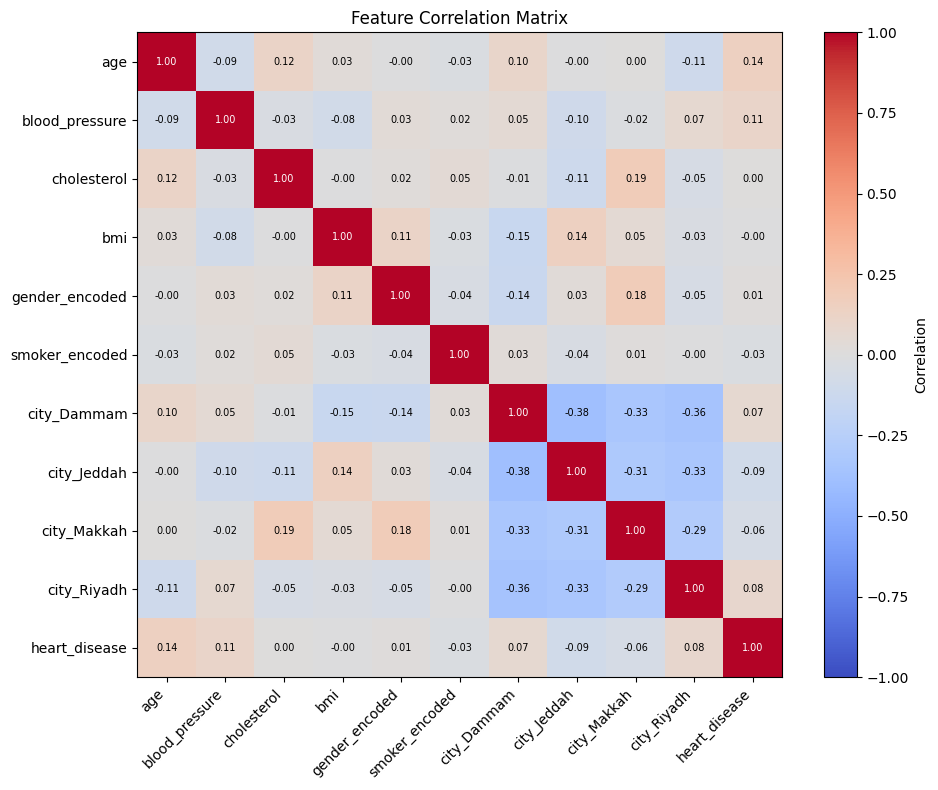

In [99]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')

# Add labels
ticks = range(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks, corr_matrix.columns)

# Add correlation values on the heatmap
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        plt.text(j, i, f'{val:.2f}', ha='center', va='center',
                 fontsize=7, color=color)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [100]:
# Select features with absolute correlation > threshold
threshold = 0.05
important_features = target_corr[abs(target_corr) > threshold]

print(f'\nFeatures with |correlation| > {threshold}:')
print(important_features.sort_values(ascending=False).round(3))

# Train with only the top features
top_features = important_features.index.tolist()
X_selected = df_processed[top_features].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

pipe_selected = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

pipe_selected.fit(X_tr, y_tr)
sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

print(f'\nAccuracy with ALL features: {pipe_acc:.2%}')
print(f'Accuracy with SELECTED features: {sel_acc:.2%}')
print(f'Features used: {len(top_features)} out of {len(feature_cols)}')


Features with |correlation| > 0.05:
age               0.143
blood_pressure    0.106
city_Riyadh       0.079
city_Dammam       0.067
city_Makkah      -0.061
city_Jeddah      -0.089
Name: heart_disease, dtype: float64

Accuracy with ALL features: 50.00%
Accuracy with SELECTED features: 55.00%
Features used: 6 out of 10


***TASK 7 :***

In [101]:
for threshold in [0.03, 0.08, 0.10]:
    important_features = target_corr[abs(target_corr) > threshold]
    top_features = important_features.index.tolist()

    X_selected = df_processed[top_features].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_selected, y, test_size=0.2, random_state=42, stratify=y
    )

    pipe_selected = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ])

    pipe_selected.fit(X_tr, y_tr)
    sel_acc = accuracy_score(y_te, pipe_selected.predict(X_te))

    print(f'Threshold={threshold:.2f} | Features={len(top_features)} | Accuracy={sel_acc:.2%}')

Threshold=0.03 | Features=6 | Accuracy=55.00%
Threshold=0.08 | Features=3 | Accuracy=55.00%
Threshold=0.10 | Features=2 | Accuracy=60.00%


The feature with the strongest correlation with `heart_disease` is the one with the highest absolute correlation value in `target_corr`.

Changing the threshold changes the number of selected features, so the model accuracy may increase or decrease.

Using fewer features can sometimes improve accuracy because it removes weak/noisy features and reduces the curse of dimensionality.

***Part 8***

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Re-create the ORIGINAL messy dataset (with missing values and string categories)
np.random.seed(42)
n = 200

data = {
    'age': np.random.randint(18, 80, n).astype(float),
    'blood_pressure': np.round(np.random.uniform(90, 180, n), 1),
    'cholesterol': np.round(np.random.uniform(150, 350, n), 1),
    'bmi': np.round(np.random.uniform(18, 42, n), 1),
    'gender': np.random.choice(['Male', 'Female'], n),
    'city': np.random.choice(['Jeddah', 'Riyadh', 'Dammam', 'Makkah'], n),
    'smoker': np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7]),
    'heart_disease': np.random.choice([0, 1], n, p=[0.6, 0.4])
}

df_full = pd.DataFrame(data)

missing_idx = np.random.choice(n, 20, replace=False)
df_full.loc[missing_idx[:10], 'age'] = np.nan
df_full.loc[missing_idx[10:15], 'blood_pressure'] = np.nan
df_full.loc[missing_idx[15:], 'cholesterol'] = np.nan

X_full = df_full.drop(columns=['heart_disease'])
y_full = df_full['heart_disease']

numeric_features = ['age', 'blood_pressure', 'cholesterol', 'bmi']
categorical_features = ['gender', 'city', 'smoker']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop=None, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

full_pipeline.fit(Xf_train, yf_train)
final_acc = accuracy_score(yf_test, full_pipeline.predict(Xf_test))

print(f'Final End-to-End Pipeline Accuracy: {final_acc:.2%}')

Final End-to-End Pipeline Accuracy: 45.00%


This pipeline is useful because it handles preprocessing and modeling in one workflow.

It applies imputation, scaling, and one-hot encoding automatically before training the classifier, which makes the process cleaner and reduces mistakes.

It is also easier to reuse and deploy because the same pipeline can be applied to new data consistently.